INTRODUCTION OF PROJECT:
This project analyzes NYC 311 customer service requests using Data Wrangling and Exploratory Data Analysis (EDA) to clean data and map complaint concentrations. It features engineering a Request_Closing_Time metric to track departmental efficiency across different city locations through advanced visualizations. Finally, it uses a Kruskal-Wallis statistical test to prove whether response times vary significantly based on the type of complaint.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.getcwd()

'C:\\Users\\jayra'

In [3]:
#Dataset Import
import pandas as pd
df = pd.read_csv("311_Service_Requests_from_2010_to_Present.csv")

C:\Users\jayra\AppData\Local\Temp\ipykernel_3428\826086903.py:3: DtypeWarning: Columns (48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("311_Service_Requests_from_2010_to_Present.csv")


In [4]:
df = pd.read_csv(
    "311_Service_Requests_from_2010_to_Present.csv",
    low_memory=False
)

In [5]:
#Understand Dataset
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [6]:
df.tail()
df.sample(5)

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
200650,30966946,06/29/2015 09:19:03 PM,06/29/2015 11:28:52 PM,NYPD,New York City Police Department,Illegal Parking,Blocked Hydrant,Street/Sidewalk,11435.0,140-55 BURDEN CRESCENT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.711065,-73.816664,"(40.71106548053346, -73.81666429978334)"
271671,30513496,04/30/2015 08:30:38 AM,NaN,NYPD,New York City Police Department,Illegal Parking,Blocked Hydrant,Street/Sidewalk,NaN,6600-6602 136TH ST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
287681,30393586,04/13/2015 08:32:01 PM,04/13/2015 09:40:13 PM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10460.0,EAST 183 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.851279,-73.883073,"(40.851279133702775, -73.88307312805603)"
68845,31852642,10/24/2015 08:02:58 PM,10/24/2015 09:11:43 PM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11238.0,22 CLAVER PLACE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.682576,-73.957578,"(40.682575727597616, -73.9575775714867)"
347113,29814803,01/28/2015 10:17:58 AM,01/28/2015 04:18:34 PM,NYPD,New York City Police Department,Blocked Driveway,Partial Access,Street/Sidewalk,11429.0,99-09 216 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.714460,-73.742880,"(40.71445959186492, -73.74287957092336)"


In [7]:
# show the each column data type
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [8]:
#show the shape of dataset
df.shape

(364558, 53)

In [9]:
#Missing values
df.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

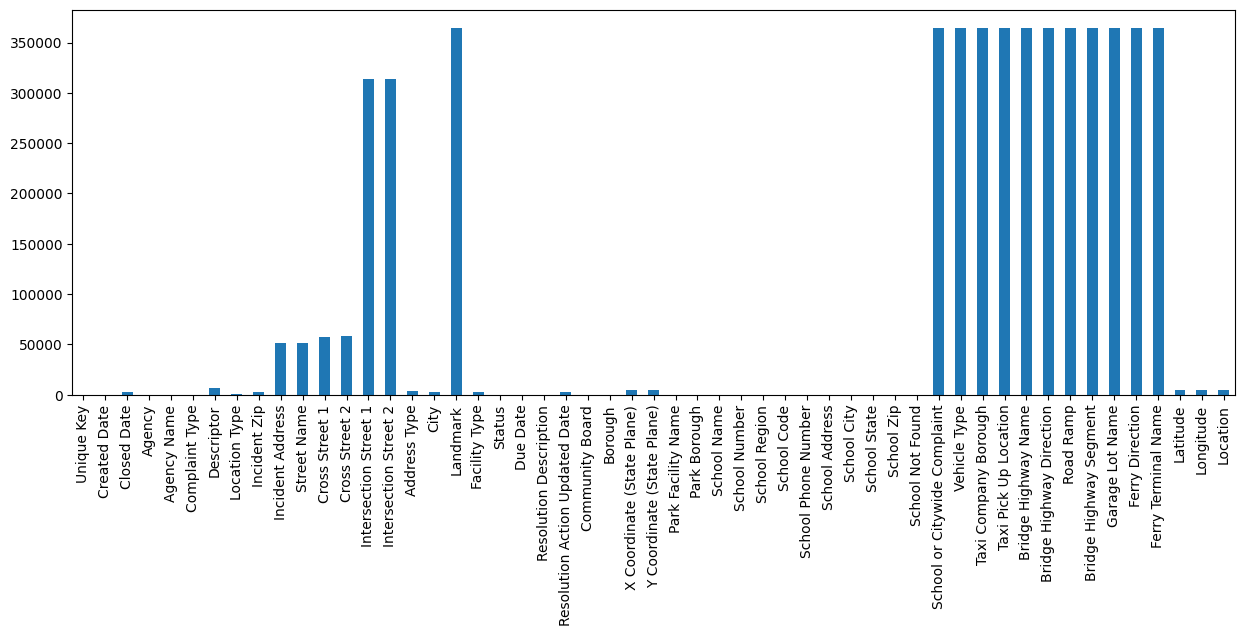

In [10]:
df.isnull().sum().plot(kind='bar', figsize=(15,5))
plt.xticks(rotation=90)
plt.show()

In [11]:
#If Closed Date is null, delete the records
df = df[df['Closed Date'].notnull()]

In [12]:
#convert the Date format
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Closed Date'] = pd.to_datetime(df['Closed Date'])

C:\Users\jayra\AppData\Local\Temp\ipykernel_3428\1322958625.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Created Date'] = pd.to_datetime(df['Created Date'])
C:\Users\jayra\AppData\Local\Temp\ipykernel_3428\1322958625.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closed Date'] = pd.to_datetime(df['Closed Date'])


In [ ]:
df = df.dropna(subset=['Created Date', 'Closed Date'])

In [ ]:
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')

df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

In [ ]:
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

In [ ]:
#closing time calculate
df['Request_Closing_Time'] = df['Closed Date'] - df['Created Date']

In [ ]:
df['Request_Closing_Time'] = df['Request_Closing_Time'].dt.total_seconds()

In [ ]:
#Statistics
df['Request_Closing_Time'].describe()

In [ ]:
df[['Complaint Type','City']].isnull().sum()

In [ ]:
df['City'] = df['City'].fillna("Unknown City")

In [ ]:
df['City'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
brooklyn = df[df['City']=="BROOKLYN"]

plt.scatter(brooklyn['Longitude'], brooklyn['Latitude'])
plt.show()

In [ ]:
plt.hexbin(brooklyn['Longitude'],
           brooklyn['Latitude'],
           gridsize=30)
plt.show()

In [ ]:
df['Complaint Type'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
ny = df[df['City']=="NEW YORK"]

ny['Complaint Type'].value_counts()

In [ ]:
df['Complaint Type'].value_counts().head(10)

In [ ]:
pd.crosstab(df['Complaint Type'],df['City'])

In [ ]:
pd.crosstab(df['Complaint Type'],df['City'])

In [ ]:
df_new = pd.crosstab(df['Complaint Type'],df['City'])

In [ ]:
df_new.plot(kind='bar',stacked=True,figsize=(15,8))
plt.show()

In [ ]:
avg = df.groupby('Complaint Type')['Request_Closing_Time'].mean()

avg.sort_values().plot(kind='bar')
plt.show()

In [ ]:
df.groupby('Complaint Type')['Request_Closing_Time'].mean()

In [25]:
!pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from scipy.stats import chi2_contingency

In [ ]:
table = pd.crosstab(df['Complaint Type'], df['City'])

In [ ]:
chi2, p, dof, expected = chi2_contingency(table)

In [ ]:
print("P-value:", p)

In [ ]:
if p < 0.05:
    print("Complaint Type and City are significantly related.")
else:
    print("Complaint Type and City are not significantly related.")

In [14]:
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

In [15]:
df = df.dropna(subset=['Created Date', 'Closed Date'])

In [16]:
df['Request_Closing_Time'] = (
    df['Closed Date'] - df['Created Date']
).dt.total_seconds()

In [17]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

Kruskal-Wallis H-statistic: 11985.0786
p-value: 0.0000e+00


Total missing values: 0
Total rows: 362177


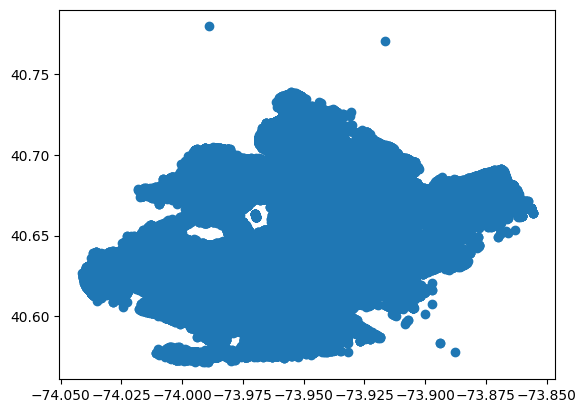

Shape of df_new Matrix: (22, 53)


City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SAINT ALBANS,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Animal Abuse,46,170,0,53,15,2,1971,3191,15,0,...,43,74,40,42,786,40,43,57,111,0
Animal in a Park,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,124,0,0,...,0,1,1,0,10,2,4,2,5,0
Blocked Driveway,50,3436,159,514,138,3,17062,36445,177,0,...,318,1202,1946,330,2845,278,279,1363,2038,27
Derelict Vehicle,32,426,14,231,120,3,2402,6257,148,0,...,248,425,356,267,2184,17,279,369,298,8


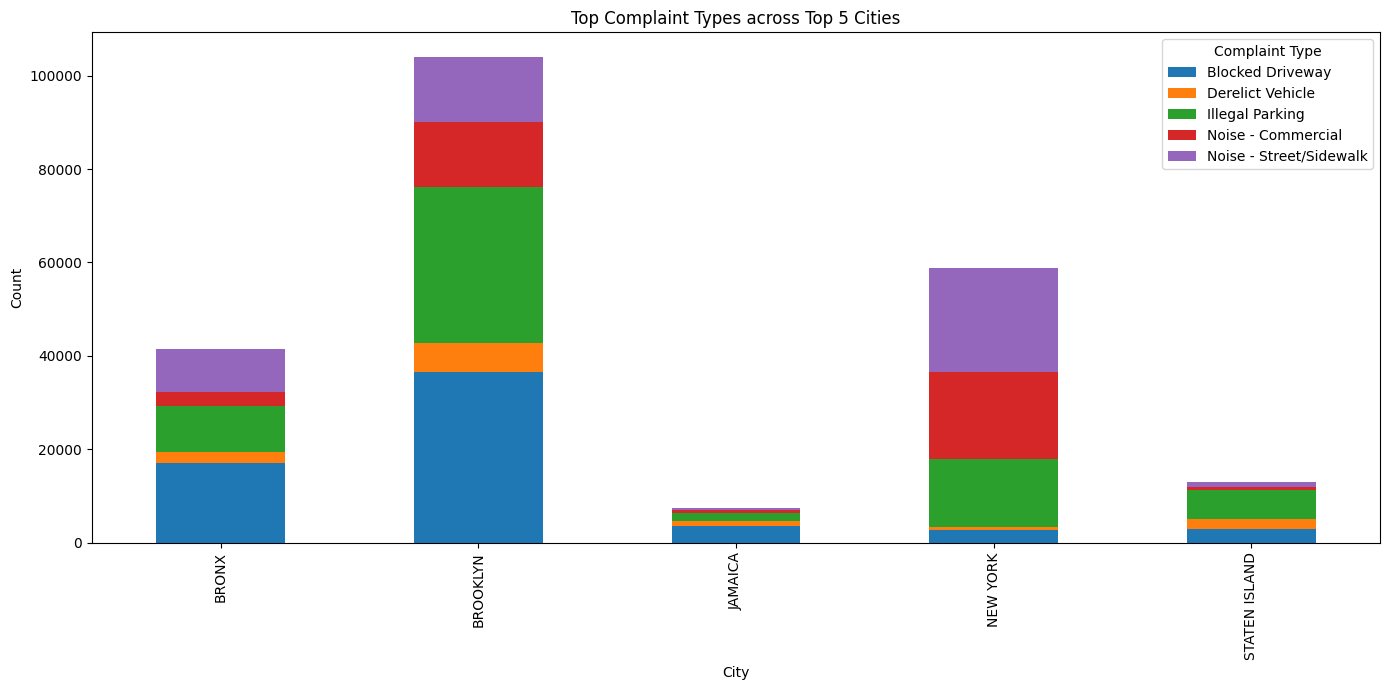

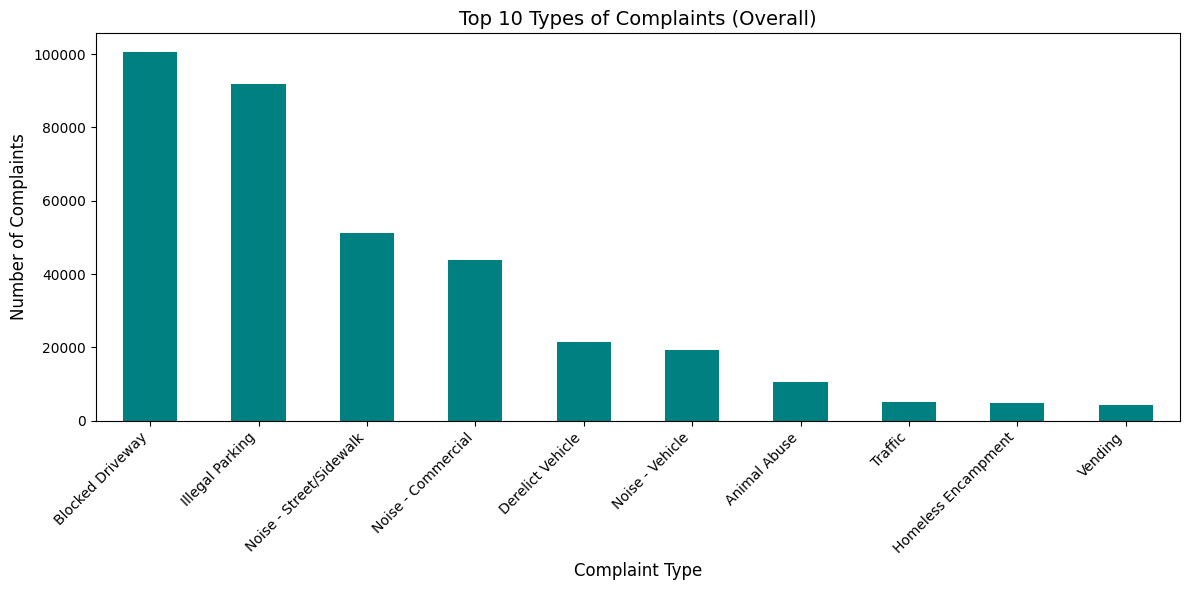

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

df['Complaint Type'].value_counts().head(10).plot(kind='bar', color='teal')

plt.title("Top 10 Types of Complaints (Overall)", fontsize=14)
plt.xlabel("Complaint Type", fontsize=12)
plt.ylabel("Number of Complaints", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

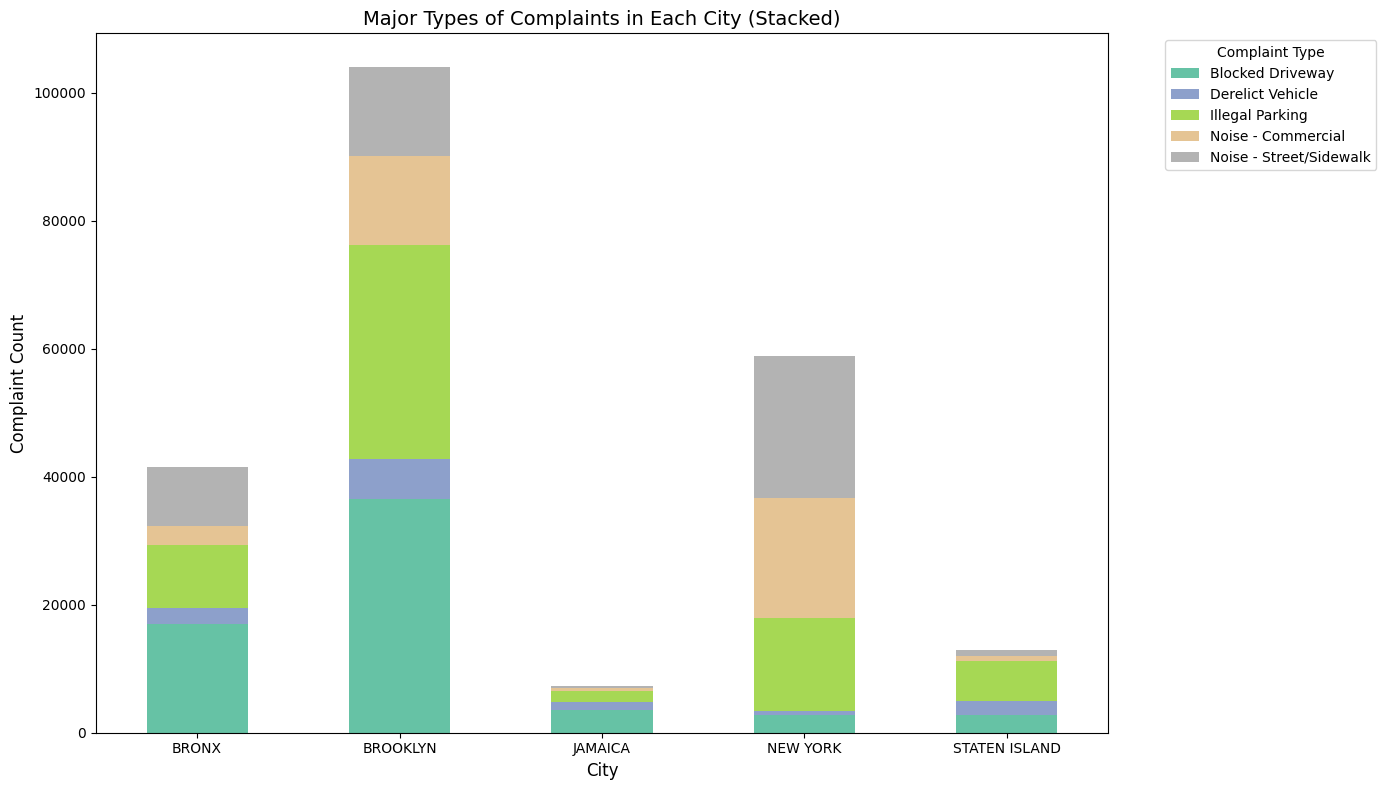

In [36]:

top_cities = df['City'].value_counts().head(5).index
top_complaints = df['Complaint Type'].value_counts().head(5).index


filtered_df = df[df['City'].isin(top_cities) & df['Complaint Type'].isin(top_complaints)]
city_complaint_matrix = pd.crosstab(filtered_df['City'], filtered_df['Complaint Type'])


city_complaint_matrix.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='Set2')

plt.title("Major Types of Complaints in Each City (Stacked)", fontsize=14)
plt.xlabel("City", fontsize=12)
plt.ylabel("Complaint Count", fontsize=12)
plt.legend(title="Complaint Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

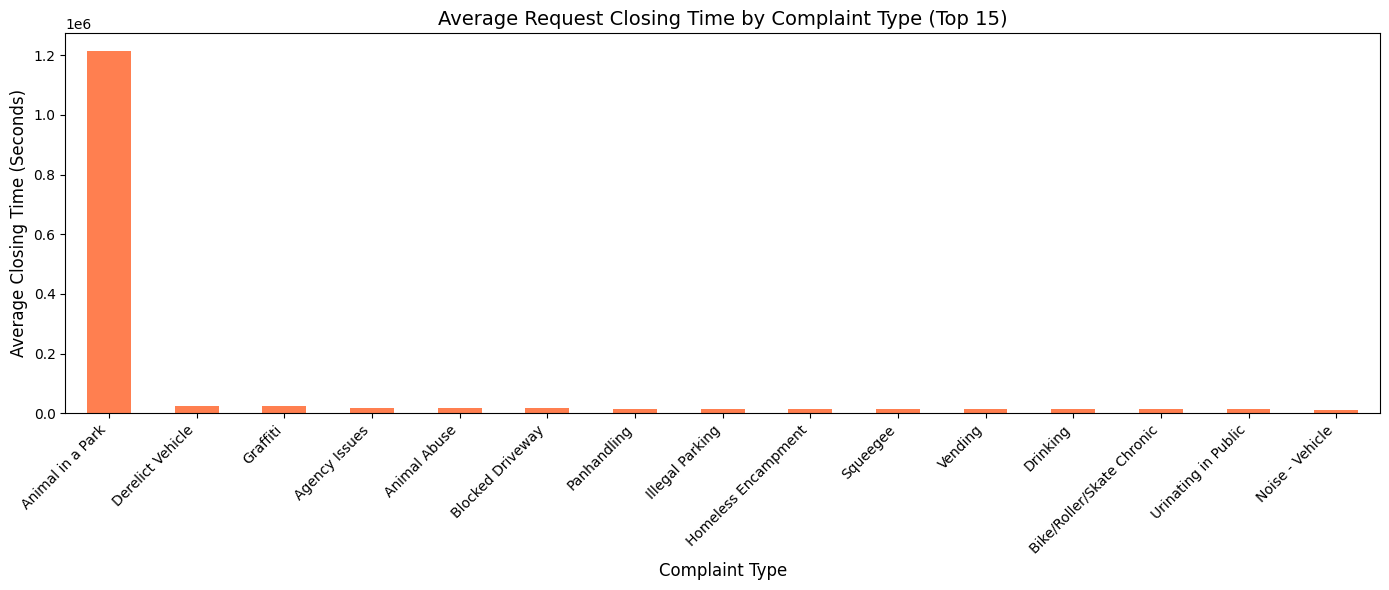

In [37]:
plt.figure(figsize=(14, 6))

df.groupby('Complaint Type')['Request_Closing_Time'].mean().sort_values(ascending=False).head(15).plot(kind='bar', color='coral')

plt.title("Average Request Closing Time by Complaint Type (Top 15)", fontsize=14)
plt.xlabel("Complaint Type", fontsize=12)
plt.ylabel("Average Closing Time (Seconds)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()